In [53]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, pairwise_distances_argmin_min
from scipy import stats
from scipy.optimize import minimize
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

# Define the target tickers list
tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJAJFINSV.NS", "BAJFINANCE.NS", "BEL.NS", "BHARTIARTL.NS",
    "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HCLTECH.NS", "HDFCBANK.NS", "HINDALCO.NS", "HINDUNILVR.NS",
    "ICICIBANK.NS", "INDIGO.NS", "INDUSINDBK.NS", "INFY.NS", "ITC.NS", 
    "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS", "M&M.NS", 
    "MARUTI.NS", "NESTLEIND.NS", "NTPC.NS", "ONGC.NS", 
    "POWERGRID.NS", "RELIANCE.NS", "SBIN.NS", "SHRIRAMFIN.NS", 
    "SUNPHARMA.NS", "TATACONSUM.NS", "TATASTEEL.NS", "TCS.NS", "TECHM.NS", 
    "TITAN.NS", "TRENT.NS", "ULTRACEMCO.NS", "WIPRO.NS"
]

# Load market data
df = pd.read_csv('StocksData.csv')

# Clean the raw dataset by isolating the closing prices, mapping tickers, formatting dates, and calculating daily returns
close_cols = [col for col in df.columns if str(col).startswith('Close')][:45]
df_close = df[['Price']+close_cols].iloc[2:].copy()
df_close.columns = ['Date'] + tickers
df_close = df_close.set_index('Date',drop=True).astype(float)
df_close.index = pd.to_datetime(df_close.index, format="%d-%m-%Y")
df_returns = df_close.pct_change().dropna()

In [54]:
df_returns

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-0.055494,-0.035881,-0.007325,0.002333,-0.025561,-0.013761,-0.012249,-0.007120,-0.004143,-0.040235,...,-0.028647,-0.020170,-0.018443,-0.001943,-0.019368,-0.007018,-0.001846,-0.025583,-0.026505,0.002246
2016-01-05,0.041128,-0.008723,0.012689,0.022537,-0.004448,0.007651,-0.006890,-0.009021,-0.002846,-0.010251,...,0.028541,0.001752,0.032359,0.067731,-0.008714,0.010651,-0.010529,-0.015542,-0.005856,-0.001434
2016-01-06,-0.026524,-0.015252,-0.008955,-0.015822,-0.013175,-0.006734,-0.003828,0.018240,-0.009333,-0.003865,...,0.008903,-0.010681,-0.020897,-0.020233,0.013900,0.006131,0.000431,-0.017036,0.000823,-0.003232
2016-01-07,-0.073043,-0.027005,-0.040334,-0.015851,-0.049803,-0.026655,-0.005932,-0.000156,-0.044037,0.000466,...,-0.058503,-0.010291,-0.035800,-0.070140,-0.004346,-0.027233,-0.010924,-0.016152,-0.024714,-0.009458
2016-01-08,0.025641,-0.014694,0.005656,0.002579,0.010874,-0.017939,0.038063,0.034096,0.003285,0.004653,...,0.024831,0.013205,0.031417,0.014806,0.011112,0.022220,0.011481,0.052418,0.014057,0.010821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,-0.011606,0.000469,0.013925,-0.007942,0.001061,0.007803,-0.005812,0.000297,0.001502,0.000377,...,0.016601,-0.010764,-0.005398,-0.004857,0.002719,-0.000919,-0.004203,0.023918,0.007364,-0.012306
2025-12-26,0.003239,-0.004818,-0.002231,-0.014001,0.001549,-0.011505,-0.008891,-0.011565,-0.003875,-0.008617,...,-0.013813,-0.010075,-0.002968,-0.005586,-0.011751,-0.011768,0.021155,-0.001002,0.002550,-0.006566
2025-12-29,-0.011974,-0.021989,-0.009992,0.010522,0.003094,0.002482,-0.002726,-0.002000,-0.013051,-0.011304,...,-0.004947,-0.001338,0.016586,0.018803,-0.008689,0.000062,-0.002079,-0.013838,0.000424,-0.007736


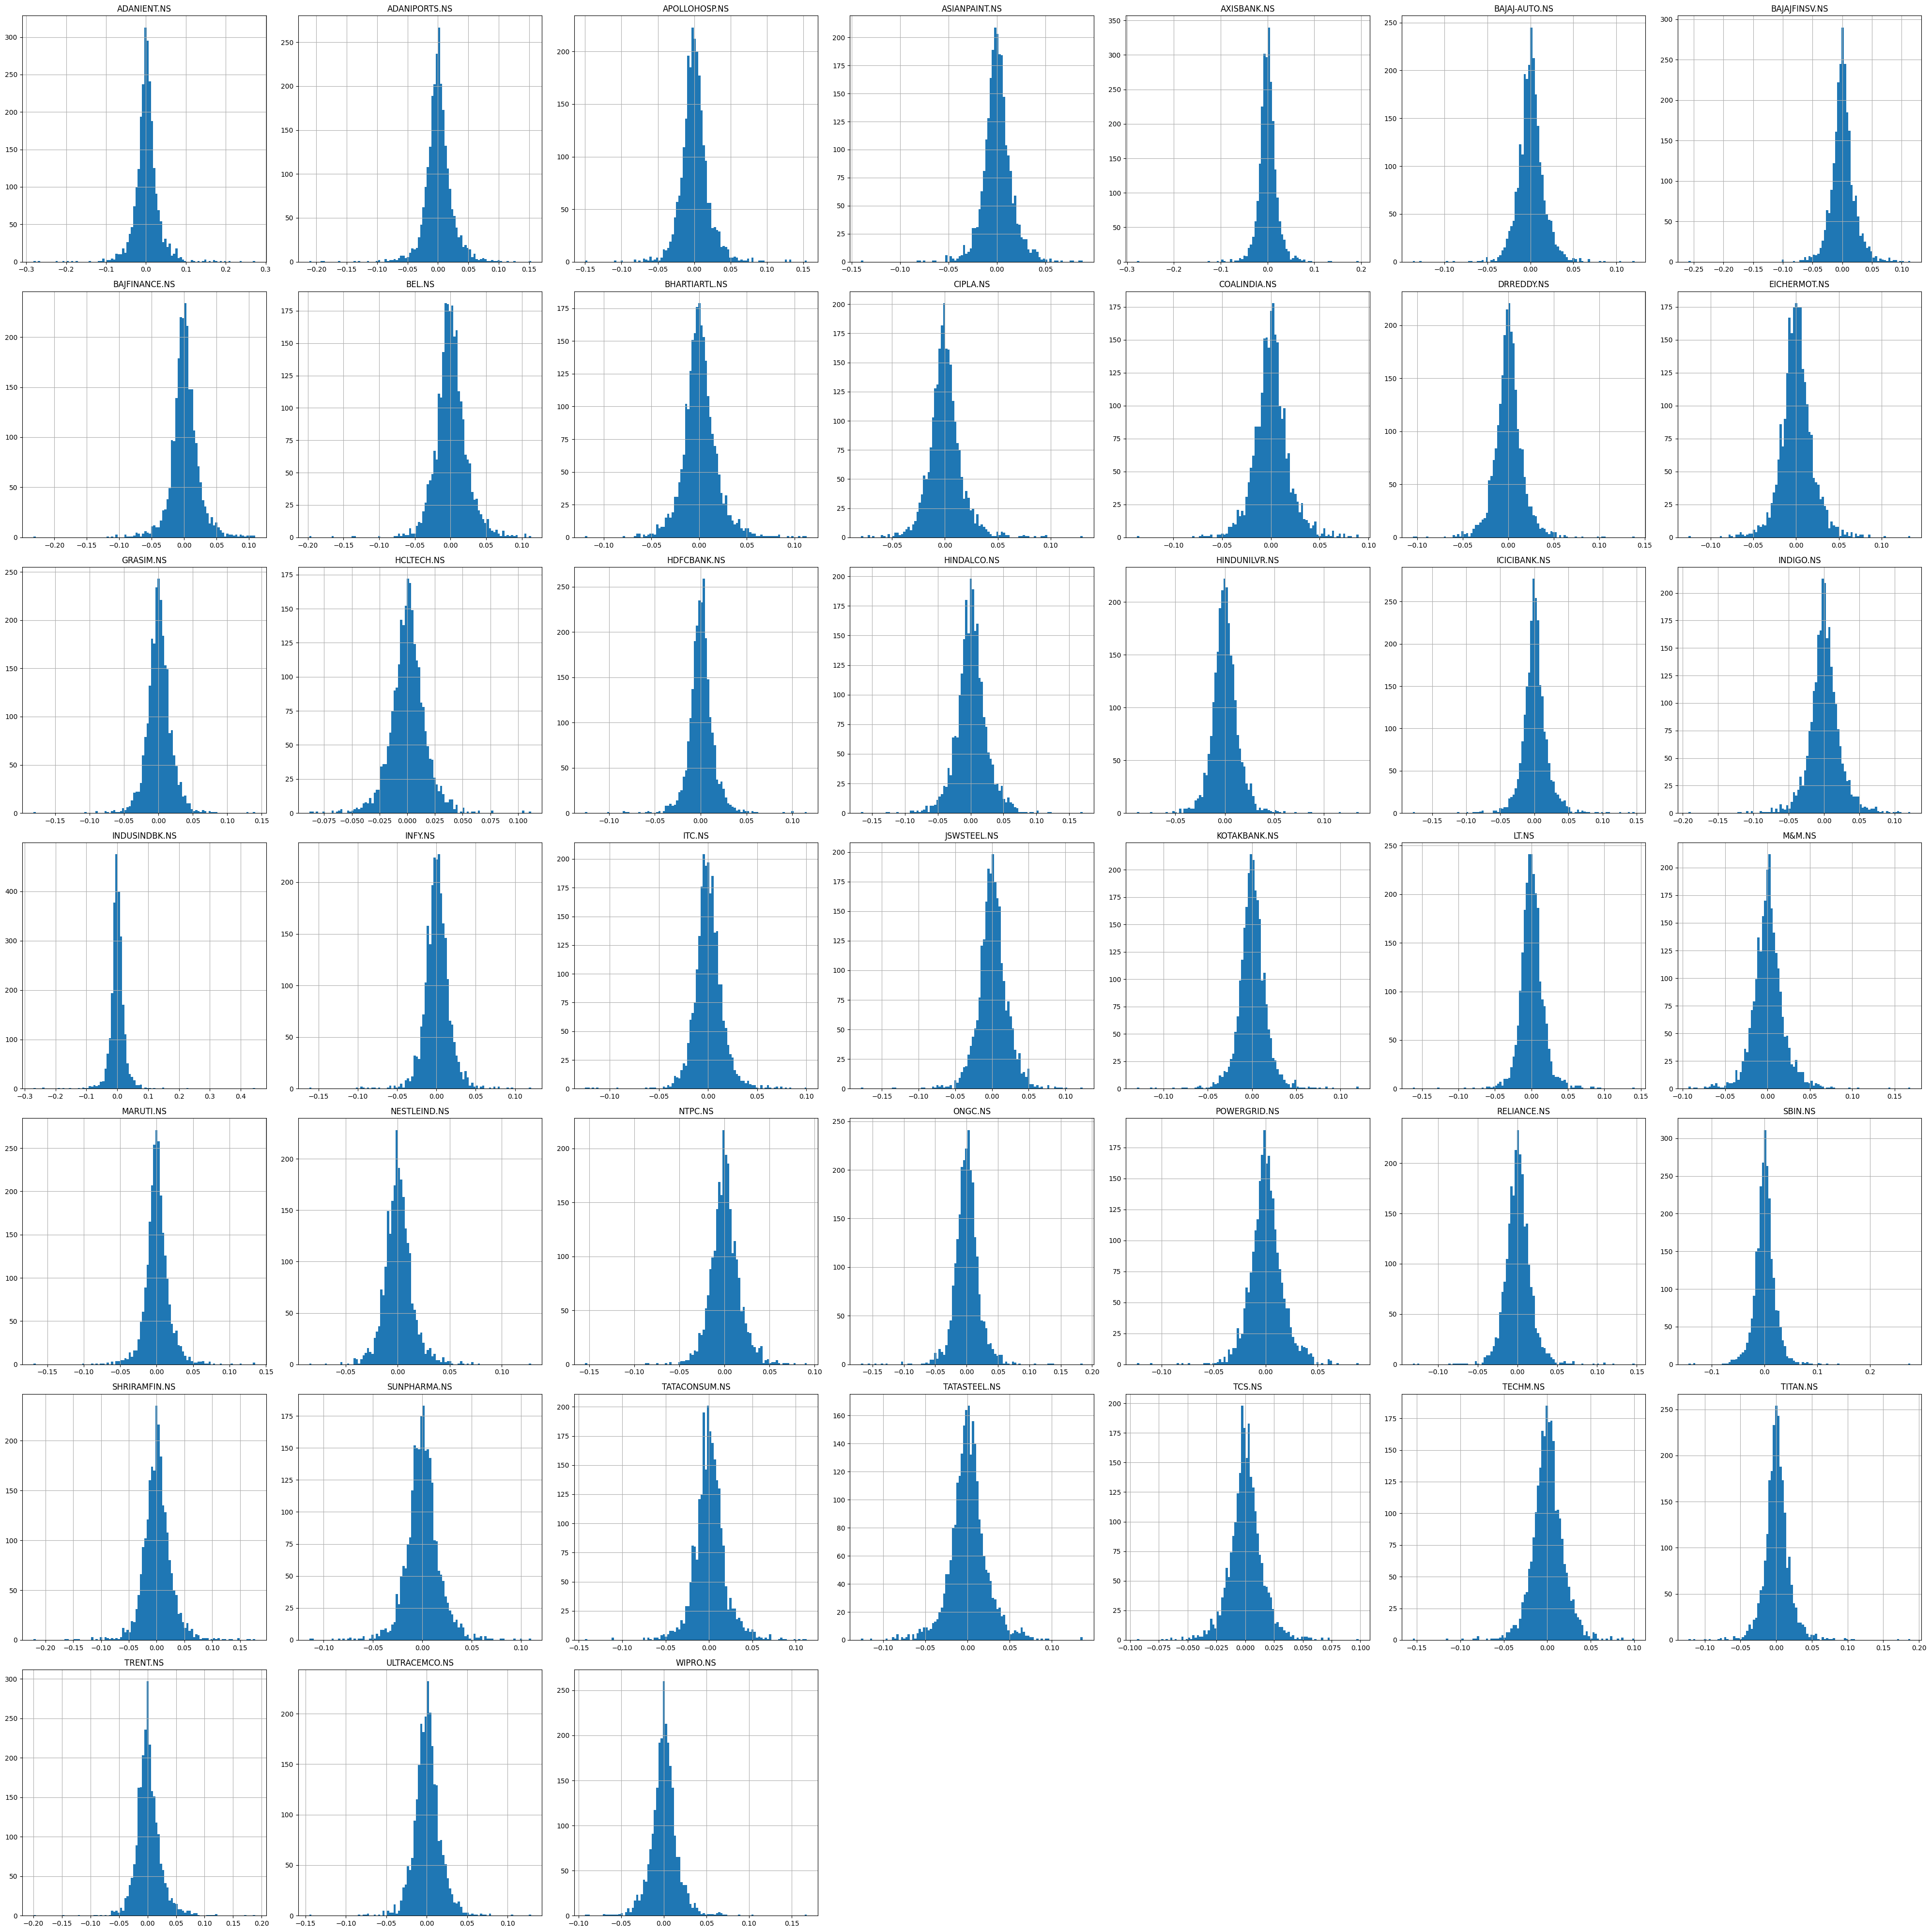

--- Goodness-of-Fit Tests for: ADANIENT.NS ---

1. Kolmogorov-Smirnov Test:
   Statistic: 0.10455
   P-Value:   5.93996e-24
   Result:    REJECT Null Hypothesis (Data is NOT Normal)

2. Cramér-von Mises Test:
   Statistic: 11.32766
   P-Value:   3.89744e-10
   Result:    REJECT Null Hypothesis (Data is NOT Normal)
--------------------------------------------------
--- Goodness-of-Fit Tests for: ADANIPORTS.NS ---

1. Kolmogorov-Smirnov Test:
   Statistic: 0.08283
   P-Value:   3.49036e-15
   Result:    REJECT Null Hypothesis (Data is NOT Normal)

2. Cramér-von Mises Test:
   Statistic: 7.71131
   P-Value:   1.17532e-09
   Result:    REJECT Null Hypothesis (Data is NOT Normal)
--------------------------------------------------
--- Goodness-of-Fit Tests for: APOLLOHOSP.NS ---

1. Kolmogorov-Smirnov Test:
   Statistic: 0.07859
   P-Value:   1.03662e-13
   Result:    REJECT Null Hypothesis (Data is NOT Normal)

2. Cramér-von Mises Test:
   Statistic: 5.31092
   P-Value:   1.56696e-10
   Res

In [55]:
df_returns.hist(figsize=(40, 40), bins=100)
plt.tight_layout()
plt.show()

def test_normality_goodness_of_fit(returns_series, asset_name="Asset"):
    """
    Runs the Kolmogorov-Smirnov and Cramér-von Mises tests to check if 
    a financial time series follows a Normal distribution.
    
    Parameters:
    returns_series (array-like): A 1D array or pandas Series of daily returns.
    asset_name (str): Label for printing.
    """
    # Standardize the data (Mean = 0, Std = 1) for a clean comparison against a standard normal distribution
    clean_data = np.asarray(returns_series).flatten()
    clean_data = clean_data[~np.isnan(clean_data)] # Drop NaNs
    
    standardized_returns = (clean_data - np.mean(clean_data)) / np.std(clean_data)

    # Kolmogorov-Smirnov (KS) Test
    ks_stat, ks_pvalue = stats.kstest(standardized_returns, 'norm')

    # Cramér-von Mises (CvM) Test
    cvm_result = stats.cramervonmises(standardized_returns, 'norm')
    cvm_stat = cvm_result.statistic
    cvm_pvalue = cvm_result.pvalue
   
    # Results
    print(f"--- Goodness-of-Fit Tests for: {asset_name} ---")
    
    print("\n1. Kolmogorov-Smirnov Test:")
    print(f"   Statistic: {ks_stat:.5f}")
    print(f"   P-Value:   {ks_pvalue:.5e}")
    if ks_pvalue < 0.05:
        print("   Result:    REJECT Null Hypothesis (Data is NOT Normal)")
    else:
        print("   Result:    FAIL TO REJECT Null Hypothesis (Data looks Normal)")
        
    print("\n2. Cramér-von Mises Test:")
    print(f"   Statistic: {cvm_stat:.5f}")
    print(f"   P-Value:   {cvm_pvalue:.5e}")
    if cvm_pvalue < 0.05:
        print("   Result:    REJECT Null Hypothesis (Data is NOT Normal)")
    else:
        print("   Result:    FAIL TO REJECT Null Hypothesis (Data looks Normal)")
    print("-" * 50)


# Test for normality for all stocks
for t in tickers:
    test_normality_goodness_of_fit(df_returns[t],t)

In [56]:
T, N = df_returns.shape
Q = T / N

# Standardize the returns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_returns)

# Compute the empirical correlation matrix
corr_matrix = np.corrcoef(X_scaled, rowvar=False)

# Calculate Eigenvalues and sort them descending
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
eigenvalues = np.sort(eigenvalues)[::-1]

# Calculate Marchenko-Pastur theoretical upper bound
# For a correlation matrix, the average variance (sigma^2) is 1 - var explained by highest eigen value
sigma_squared = 1 - eigenvalues[0]/N
lambda_max = sigma_squared * (1 + np.sqrt(1/Q))**2

# Hypothesis Test: Count how many PCs beat the noise threshold
signal_eigenvalues = eigenvalues[eigenvalues > lambda_max]
optimal_k = len(signal_eigenvalues)

print("="*50)
print("RANDOM MATRIX THEORY: EIGENVALUE HYPOTHESIS TEST")
print("="*50)
print(f"Matrix Dimensions:        T = {T} days, N = {N} stocks")
print(f"Theoretical Noise Bound:  Lambda Max = {lambda_max:.4f}")
print("-" * 50)
print(f"Number of PCs > Noise:    {optimal_k}")
print(f"Variance Explained by {optimal_k} PCs: {(np.sum(signal_eigenvalues) / N * 100):.2f}%")
print("="*50)

# Print the top eigenvalues to see the cutoff
for i, val in enumerate(eigenvalues[:optimal_k + 3]):
    status = "SIGNAL" if val > lambda_max else "NOISE"
    print(f"PC {i+1}: Eigenvalue = {val:.4f}  [{status}]")

RANDOM MATRIX THEORY: EIGENVALUE HYPOTHESIS TEST
Matrix Dimensions:        T = 2469 days, N = 45 stocks
Theoretical Noise Bound:  Lambda Max = 0.8957
--------------------------------------------------
Number of PCs > Noise:    9
Variance Explained by 9 PCs: 56.25%
PC 1: Eigenvalue = 13.7120  [SIGNAL]
PC 2: Eigenvalue = 2.5648  [SIGNAL]
PC 3: Eigenvalue = 2.0252  [SIGNAL]
PC 4: Eigenvalue = 1.6353  [SIGNAL]
PC 5: Eigenvalue = 1.2671  [SIGNAL]
PC 6: Eigenvalue = 1.1051  [SIGNAL]
PC 7: Eigenvalue = 1.0539  [SIGNAL]
PC 8: Eigenvalue = 1.0012  [SIGNAL]
PC 9: Eigenvalue = 0.9497  [SIGNAL]
PC 10: Eigenvalue = 0.8913  [NOISE]
PC 11: Eigenvalue = 0.8716  [NOISE]
PC 12: Eigenvalue = 0.8189  [NOISE]


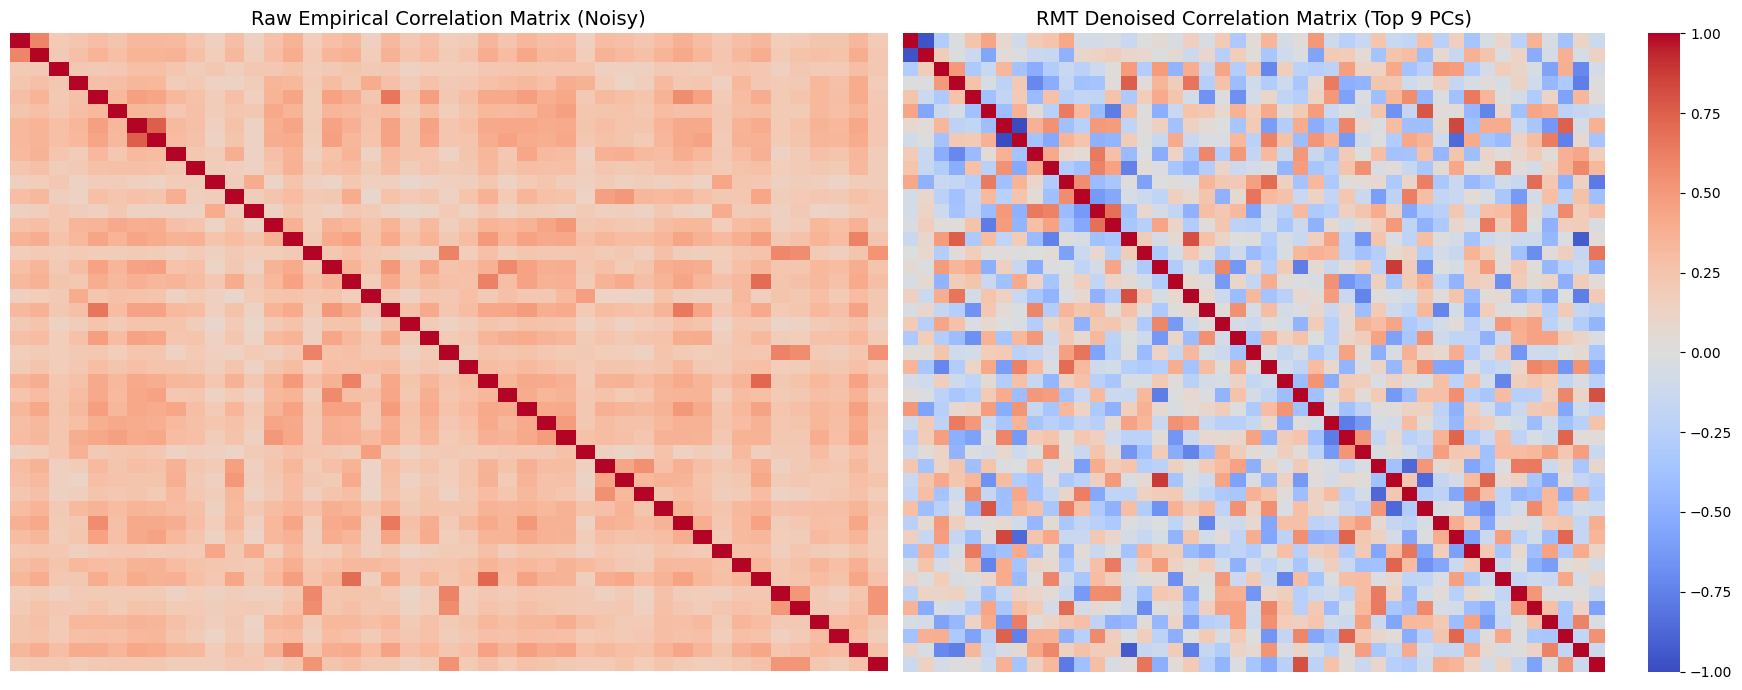

In [57]:
# Reconstruct the Denoised Correlation Matrix
# We use only the signal eigenvectors and eigenvalues from RMT step
signal_eigenvectors = eigenvectors[:, :optimal_k]
signal_eigenvalues_diag = np.diag(eigenvalues[:optimal_k])

# C_denoised = V * Lambda * V^T
denoised_cov = np.dot(np.dot(signal_eigenvectors, signal_eigenvalues_diag), signal_eigenvectors.T)

# Convert covariance back to correlation (normalize diagonals to 1)
d = np.sqrt(np.diag(denoised_cov))
denoised_corr = denoised_cov / np.outer(d, d)
np.fill_diagonal(denoised_corr, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw Empirical Correlation
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], 
            xticklabels=False, yticklabels=False, cbar=False)
axes[0].set_title('Raw Empirical Correlation Matrix (Noisy)', fontsize=14)

# Plot 2: RMT Denoised Correlation
sns.heatmap(denoised_corr, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], 
            xticklabels=False, yticklabels=False)
axes[1].set_title(f'RMT Denoised Correlation Matrix (Top {optimal_k} PCs)', fontsize=14)

plt.tight_layout()
plt.show()

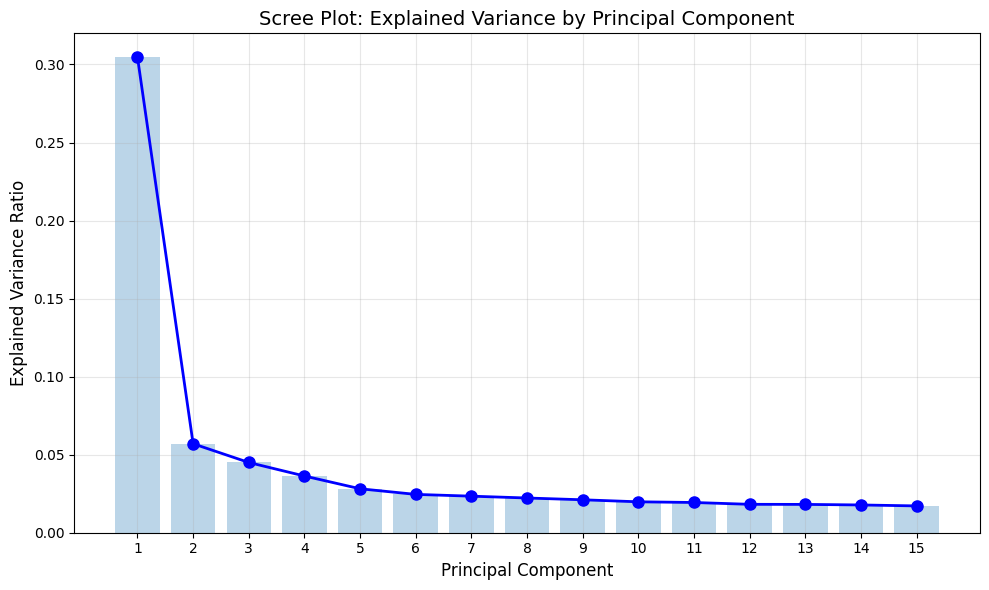

Explained Variance by Top 5 PCs: 0.4712102229774191

First 5 Stocks and their PC Loadings:
                    PC1       PC2       PC3       PC4       PC5
ADANIENT.NS    0.144180 -0.062694  0.093972 -0.005296 -0.026508
ADANIPORTS.NS  0.162351 -0.065939  0.101646 -0.020643 -0.037505
APOLLOHOSP.NS  0.111913  0.069126 -0.052276  0.189274  0.075660
ASIANPAINT.NS  0.134925  0.041369 -0.264576  0.147154 -0.224344
AXISBANK.NS    0.178191 -0.121732 -0.074001 -0.157878  0.187049


In [58]:
# STANDARDIZE RETURNS

# PCA is highly sensitive to variance. We must standardize so high-volatility 
# stocks don't artificially dominate the principal components.
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(df_returns)

 
# FIT PCA & EXTRACT LOADINGS
n_components = 15
pca = PCA(n_components=n_components)
pca.fit(scaled_returns)

# Create a scree plot to visualize explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.3)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot: Explained Variance by Principal Component', fontsize=14)
plt.xticks(range(1, n_components + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Let's extract the top 5 Principal Components
n_components = 5
pca = PCA(n_components=n_components)
pca.fit(scaled_returns)

# Now, every stock is represented by a vector of 5 PC loadings.
loadings_matrix = pca.components_.T 

df_loadings = pd.DataFrame(
    loadings_matrix, 
    index=df_returns.columns, 
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print("Explained Variance by Top 5 PCs:", pca.explained_variance_ratio_.sum())
print("\nFirst 5 Stocks and their PC Loadings:")
print(df_loadings.head())

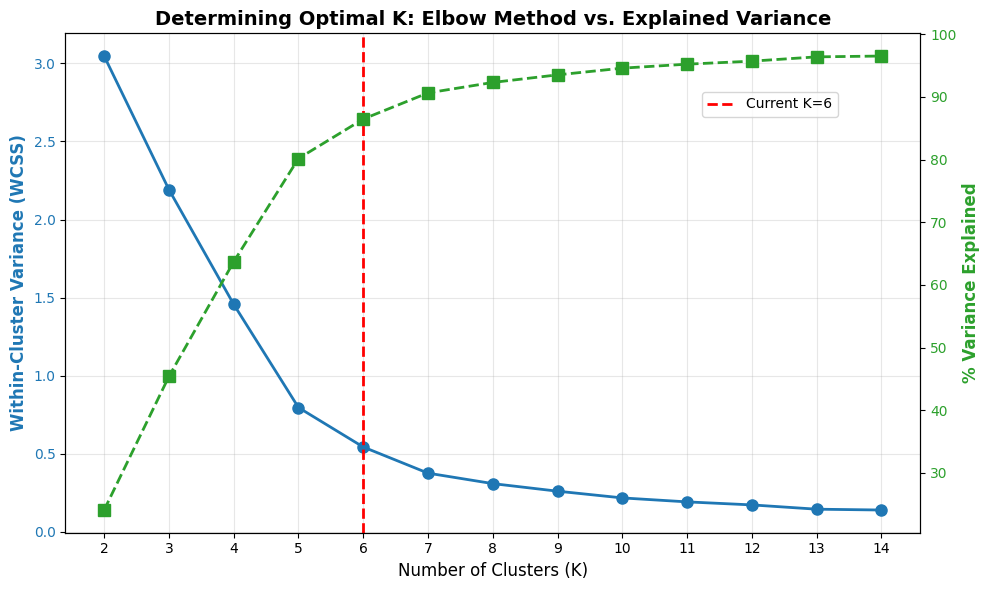

In [59]:
# We will test K values from 2 to 15
k_values = range(2, 15)
wcss_scores = []
explained_variances = []

# Calculate the Total Variance of the system to find the % explained
global_mean = df_loadings.mean(axis=0).values
total_variance = np.sum((df_loadings.values - global_mean) ** 2)

for k in k_values:
    # Initialize and fit KMeans for the current K
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(df_loadings)
    
    # WCSS is directly available as the inertia_ attribute
    wcss = kmeans.inertia_
    wcss_scores.append(wcss)
    
    # Calculate % Variance Explained
    # Between-Cluster Sum of Squares (BCSS) = Total Variance - WCSS
    bcss = total_variance - wcss
    pct_explained = (bcss / total_variance) * 100
    explained_variances.append(pct_explained)

 
# GENERATE DUAL-AXIS ELBOW PLOT
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: WCSS (The Elbow) on the left Y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Within-Cluster Variance (WCSS)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(k_values, wcss_scores, 'bo-', linewidth=2, markersize=8, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Plot 2: % Variance Explained on the right Y-axis
ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('% Variance Explained', color=color2, fontsize=12, fontweight='bold')  
ax2.plot(k_values, explained_variances, 's--', linewidth=2, markersize=8, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Highlight your currently chosen K=6
ax1.axvline(x=6, color='red', linestyle='--', linewidth=2, label='Current K=6')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))

plt.title('Determining Optimal K: Elbow Method vs. Explained Variance', fontsize=14, fontweight='bold')
plt.xticks(k_values)
fig.tight_layout()  
plt.show()

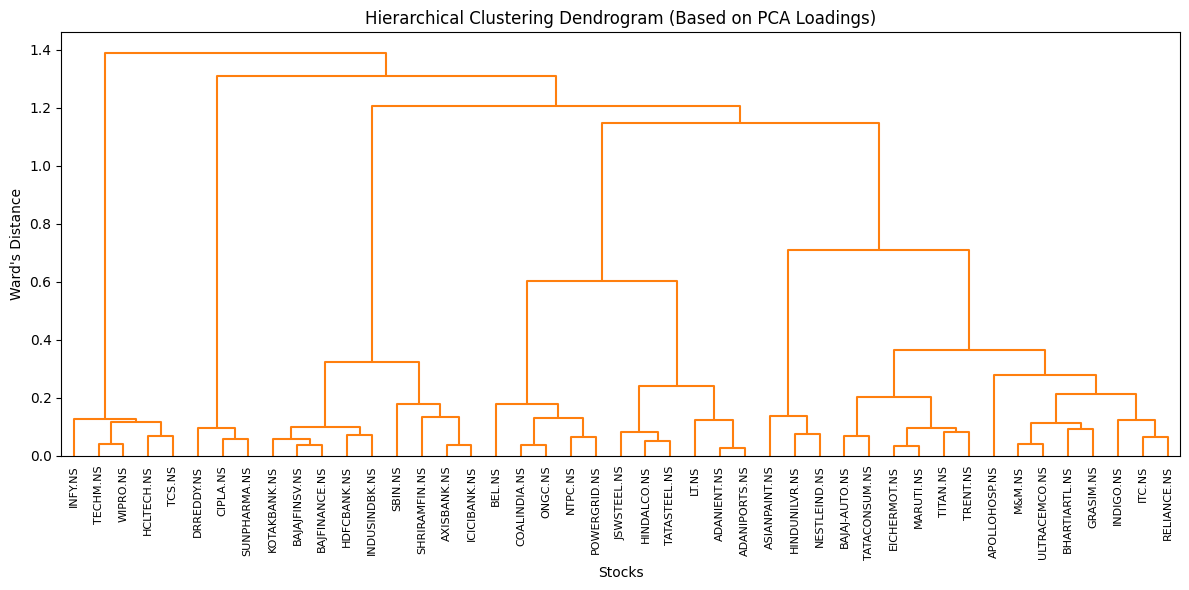


CLUSTER SEPARATION DIAGNOSTICS
Silhouette Score:           0.5188 (Higher is better)
Calinski-Harabasz Index:    48.3935 (Higher is better)
Davies-Bouldin Index:       0.6311 (Lower is better)

--- Specific Cluster Breakdown ---
Cluster 1:  5 stocks | WCSS: 0.0180 | Avg Variance: 0.0036
Cluster 2:  3 stocks | WCSS: 0.0066 | Avg Variance: 0.0022
Cluster 3:  9 stocks | WCSS: 0.0879 | Avg Variance: 0.0098
Cluster 4: 11 stocks | WCSS: 0.2503 | Avg Variance: 0.0228
Cluster 5:  3 stocks | WCSS: 0.0123 | Avg Variance: 0.0041
Cluster 6: 14 stocks | WCSS: 0.1819 | Avg Variance: 0.0130
-----------------------------------------
Total Within-Cluster Variance (WCSS):  0.5569 (Keep Low)
Total Between-Cluster Variance (BCSS): 3.4555 (Keep High)
Total Variance (WCSS + BCSS):          4.0124

% Variance Explained by Clusters:      86.12%


In [60]:
# HIERARCHICAL CLUSTERING ON LOADINGS
Z = linkage(df_loadings, method='ward')

# VISUALIZATION & LABEL EXTRACTION 
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Based on PCA Loadings)")
plt.xlabel("Stocks")
plt.ylabel("Ward's Distance")

# Draw the dendrogram
dendrogram(
    Z,
    labels=df_loadings.index,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=3.5 
)
plt.tight_layout()
plt.show()

# Extract actual cluster labels
num_clusters = 6
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

df_clusters = pd.DataFrame({
    'Stock': df_loadings.index,
    'Cluster': cluster_labels
})

 
# CLUSTER DIAGNOSTICS & SEPARATION METRICS
print("\n" + "="*45)
print("CLUSTER SEPARATION DIAGNOSTICS")
print("="*45)

# Global Metrics (Scikit-Learn)
# Silhouette: [-1 to +1]. Measures distance to own cluster vs nearest neighboring cluster. >0.3 is decent for financial data.
sil_score = silhouette_score(df_loadings, cluster_labels)
# Calinski-Harabasz: Ratio of Between-Cluster Variance to Within-Cluster Variance. Higher is better.
ch_score = calinski_harabasz_score(df_loadings, cluster_labels)
# Davies-Bouldin: Average similarity measure of each cluster with its most similar cluster. Lower is better.
db_score = davies_bouldin_score(df_loadings, cluster_labels)

print(f"Silhouette Score:           {sil_score:.4f} (Higher is better)")
print(f"Calinski-Harabasz Index:    {ch_score:.4f} (Higher is better)")
print(f"Davies-Bouldin Index:       {db_score:.4f} (Lower is better)\n")

# Manual Variance Calculations (WCSS & BCSS)
global_centroid = df_loadings.mean(axis=0).values
total_wcss = 0
bcss = 0

print("--- Specific Cluster Breakdown ---")
for cluster_id in range(1, num_clusters + 1):
    # Isolate stocks in this cluster
    cluster_mask = cluster_labels == cluster_id
    cluster_points = df_loadings[cluster_mask].values
    cluster_size = len(cluster_points)
    
    # Calculate Cluster Centroid
    cluster_centroid = cluster_points.mean(axis=0)
    
    # Calculate Within-Cluster Sum of Squares (WCSS) for this cluster
    # (Sum of squared distances from each point to its own centroid)
    wcss_k = np.sum((cluster_points - cluster_centroid) ** 2)
    total_wcss += wcss_k
    
    # Calculate Between-Cluster Sum of Squares (BCSS) contribution
    # (Size of cluster * squared distance from cluster centroid to global centroid)
    bcss_k = cluster_size * np.sum((cluster_centroid - global_centroid) ** 2)
    bcss += bcss_k
    
    # Calculate variance (Mean Squared Error) for context
    cluster_variance = wcss_k / cluster_size if cluster_size > 0 else 0
    
    print(f"Cluster {cluster_id}: {cluster_size:2d} stocks | WCSS: {wcss_k:.4f} | Avg Variance: {cluster_variance:.4f}")

print("-" * 41)
print(f"Total Within-Cluster Variance (WCSS):  {total_wcss:.4f} (Keep Low)")
print(f"Total Between-Cluster Variance (BCSS): {bcss:.4f} (Keep High)")
print(f"Total Variance (WCSS + BCSS):          {(total_wcss + bcss):.4f}")
# Calculate Variance Explained by Clusters (R-squared of Clustering)
r_squared = bcss / (total_wcss + bcss)
print(f"\n% Variance Explained by Clusters:      {(r_squared * 100):.2f}%")

In [61]:
# K-MEANS CLUSTERING
num_clusters = 6

# Initialize and fit K-Means
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_loadings)

# Create a DataFrame for the results
df_kmeans = pd.DataFrame({
    'Stock': df_loadings.index,
    'Cluster': cluster_labels + 1  # +1 so clusters are 1, 2, 3, 4 instead of 0, 1, 2, 3
})

# DIAGNOSTICS & METRICS
print("\n" + "="*50)
print("K-MEANS CLUSTER SEPARATION DIAGNOSTICS")
print("="*50)

# A. Global Scikit-Learn Metrics
sil_score = silhouette_score(df_loadings, cluster_labels)
ch_score = calinski_harabasz_score(df_loadings, cluster_labels)
db_score = davies_bouldin_score(df_loadings, cluster_labels)

print(f"Silhouette Score:           {sil_score:.4f} (Target: > 0.3)")
print(f"Calinski-Harabasz Index:    {ch_score:.4f} (Higher is better)")
print(f"Davies-Bouldin Index:       {db_score:.4f} (Lower is better)\n")

# B. Variance Diagnostics (WCSS & BCSS)
# K-Means gives us WCSS directly via the 'inertia_' attribute
wcss = kmeans.inertia_

# To find Total Variance, we calculate the variance of all points from the global mean
global_mean = df_loadings.mean(axis=0).values
total_variance = np.sum((df_loadings.values - global_mean) ** 2)

# BCSS is simply Total Variance minus WCSS
bcss = total_variance - wcss
r_squared = bcss / total_variance

print("--- Variance Breakdown ---")
print(f"Total Within-Cluster Variance (WCSS):  {wcss:.4f} (Algorithm minimized this)")
print(f"Total Between-Cluster Variance (BCSS): {bcss:.4f}")
print(f"Total System Variance:                 {total_variance:.4f}")
print(f"% Variance Explained by Clusters:      {(r_squared * 100):.2f}%\n")

# C. Cluster-Specific Breakdown
centroids = kmeans.cluster_centers_

print("--- Cluster Profiles ---")
for k in range(num_clusters):
    cluster_mask = cluster_labels == k
    size = np.sum(cluster_mask)
    
    # Calculate WCSS specifically for this cluster
    cluster_points = df_loadings[cluster_mask].values
    cluster_wcss = np.sum((cluster_points - centroids[k]) ** 2)
    
    print(f"Cluster {k+1}: {size:2d} stocks | Internal WCSS: {cluster_wcss:.4f}")


K-MEANS CLUSTER SEPARATION DIAGNOSTICS
Silhouette Score:           0.5189 (Target: > 0.3)
Calinski-Harabasz Index:    49.8272 (Higher is better)
Davies-Bouldin Index:       0.6153 (Lower is better)

--- Variance Breakdown ---
Total Within-Cluster Variance (WCSS):  0.5431 (Algorithm minimized this)
Total Between-Cluster Variance (BCSS): 3.4693
Total System Variance:                 4.0124
% Variance Explained by Clusters:      86.46%

--- Cluster Profiles ---
Cluster 1: 10 stocks | Internal WCSS: 0.2034
Cluster 2:  5 stocks | Internal WCSS: 0.0180
Cluster 3:  3 stocks | Internal WCSS: 0.0123
Cluster 4:  3 stocks | Internal WCSS: 0.0066
Cluster 5: 10 stocks | Internal WCSS: 0.1209
Cluster 6: 14 stocks | Internal WCSS: 0.1819


In [62]:
num_clusters = 6
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_loadings[['PC1', 'PC2', 'PC3']]) # Fit on top 3 for exact visual match
centroids = kmeans.cluster_centers_

# Add labels back to the dataframe for hover data
df_plot = df_loadings.copy()
df_plot['Cluster'] = (cluster_labels + 1).astype(str) 
df_plot['Stock'] = df_plot.index

 
# GENERATE INTERACTIVE 3D SCATTER PLOT
# Plot the individual stocks
fig = px.scatter_3d(
    df_plot, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Cluster',
    hover_name='Stock', 
    title="3D Market Structure (PC1 vs PC2 vs PC3)",
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.7
)

# Add the mathematical centroids as large black X markers
fig.add_trace(
    go.Scatter3d(
        x=centroids[:, 0],
        y=centroids[:, 1],
        z=centroids[:, 2],
        mode='markers',
        marker=dict(
            size=10,
            color='black',
            symbol='x',
            line=dict(color='white', width=2)
        ),
        name='Centroids',
        hoverinfo='name'
    )
)

# Clean up the layout and grid
fig.update_layout(
    scene=dict(
        xaxis_title='PC1 (Market Factor)',
        yaxis_title='PC2 (Sector Factor A)',
        zaxis_title='PC3 (Sector Factor B)',
        bgcolor='rgb(240, 240, 240)'
    ),
    margin=dict(l=0, r=0, b=0, t=40) 
)

# Display the interactive plot in your notebook
fig.show()

In [63]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

features = pd.read_csv('NiftyData.csv')
features['Date'] = pd.to_datetime(features['Date'], format="%d-%m-%Y")
features.set_index('Date', inplace=True)
# Drop NaN rows created by rolling windows and shifts
features = features.dropna()

print(f"Feature Space Built: {features.shape[0]} days, {features.shape[1]} features.")

Feature Space Built: 2380 days, 3 features.


In [64]:
features

,Close,VIX,Oil
Date,,,
2016-01-05,7784.649902,16.700001,35.970001
2016-01-06,7741.000000,16.549999,33.970001
2016-01-07,7568.299805,18.959999,33.270000
2016-01-08,7601.350098,17.799999,33.160000
2016-01-11,7563.850098,18.690001,31.410000
...,...,...,...
2025-12-24,26142.099610,9.190000,58.349998
2025-12-26,26042.300780,9.150000,56.740002
2025-12-29,25942.099610,9.720000,58.080002


--- Regime Diagnostics ---
                  Days_in_Regime  Ann_Return  Ann_Vol  Ann_Sharpe  Mean_VIX  \
Regime_Name                                                                   
1. Bull Calm                1036      0.2609   0.1042      2.5050   13.8246   
2. Bull Volatile             480      0.1445   0.1717      0.8414   20.3756   
3. Bear Calm                 499      0.0825   0.1268      0.6503   14.2704   
4. Bear Volatile             339     -0.1520   0.3023     -0.5030   22.6631   

                  Mean_Oil_Return  
Regime_Name                        
1. Bull Calm              -0.0011  
2. Bull Volatile           0.0063  
3. Bear Calm              -0.0025  
4. Bear Volatile           0.0020  


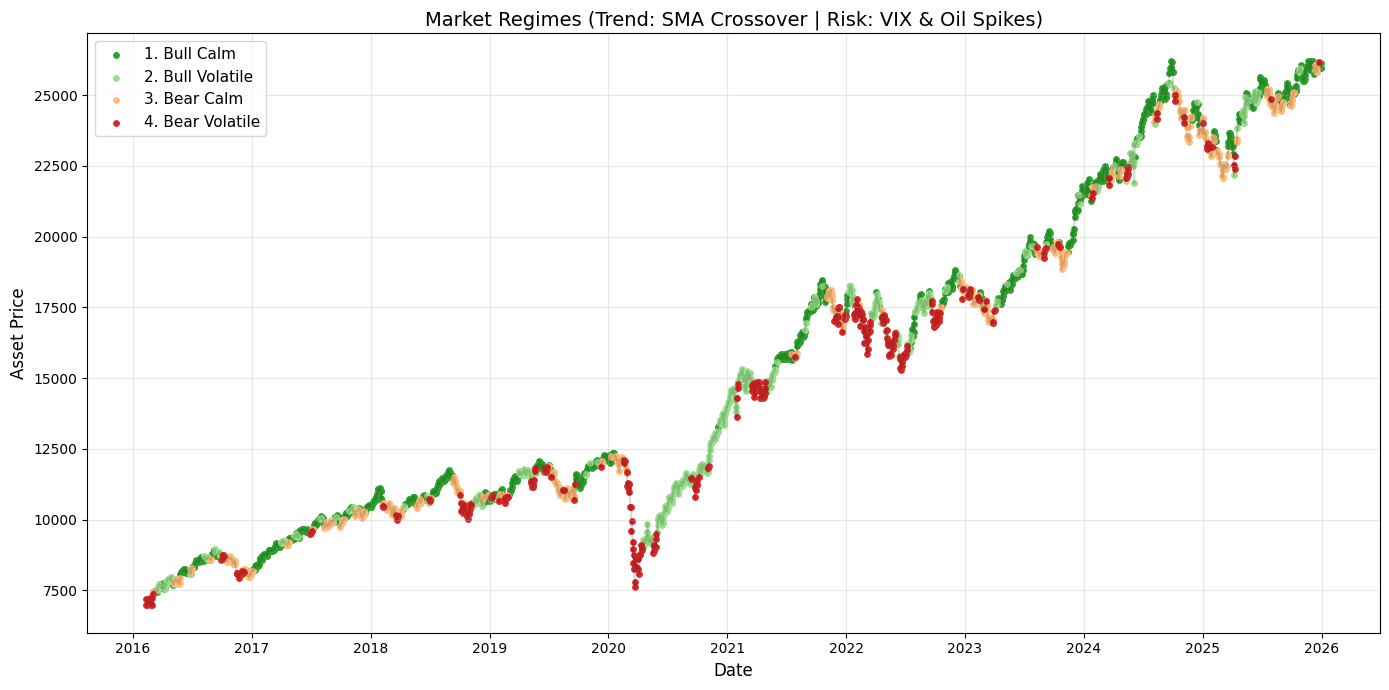

In [65]:
# FEATURE ENGINEERING
df = features.copy()
# Calculate Returns
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Oil_Returns'] = np.log(df['Oil'] / df['Oil'].shift(1))

# Trend Indicators (5-day and 25-day SMA) Weekly vs Monthly
df['SMA5'] = df['Close'].rolling(window=5).mean()
df['SMA25'] = df['Close'].rolling(window=25).mean()

# Drop NaNs generated by the rolling windows
df = df.dropna()

# DEFINE REGIMES USING VIX & OIL
# Risk Thresholds
# We use the 75th percentile of VIX as the "High Volatility" baseline
vix_thresh = df['VIX'].quantile(0.75)

# Macro Overlay: If Oil spikes more than 5% over 5 days, we flag a risk event
df['Oil_Spike'] = df['Oil'].pct_change(5) > 0.05

# Trend Condition: 1 if Bullish (Fast SMA > Slow SMA), 0 if Bearish
trend = np.where(df['SMA5'] > df['SMA25'], 1, 0)

# Volatility Condition: 1 if High Risk (VIX is high OR Oil is spiking)
volatility = np.where((df['VIX'] > vix_thresh) | (df['Oil_Spike']), 1, 0)

# Initialize Regimes array
df['Regime'] = np.zeros(len(df), dtype=int)

# Map conditions to your 4 Regimes
df.loc[(trend == 1) & (volatility == 0), 'Regime'] = 1 # Bull Calm
df.loc[(trend == 1) & (volatility == 1), 'Regime'] = 2 # Bull Volatile
df.loc[(trend == 0) & (volatility == 0), 'Regime'] = 3 # Bear Calm
df.loc[(trend == 0) & (volatility == 1), 'Regime'] = 4 # Bear Volatile

# Add string names for easier reading
df['Regime_Name'] = df['Regime'].map({
    1: '1. Bull Calm', 
    2: '2. Bull Volatile', 
    3: '3. Bear Calm', 
    4: '4. Bear Volatile'
})

# REGIME DIAGNOSTICS
diagnostics = df.groupby('Regime_Name').agg(
    Days_in_Regime=('Returns', 'count'),
    Mean_Daily_Return=('Returns', 'mean'),
    Daily_Vol=('Returns', 'std'),
    Mean_VIX=('VIX', 'mean'),
    Mean_Oil_Return=('Oil_Returns', 'mean')
)

# Annualize metrics for standard reporting
diagnostics['Ann_Return'] = diagnostics['Mean_Daily_Return'] * 252
diagnostics['Ann_Vol'] = diagnostics['Daily_Vol'] * np.sqrt(252)
diagnostics['Ann_Sharpe'] = diagnostics['Ann_Return'] / diagnostics['Ann_Vol']

display_cols = ['Days_in_Regime', 'Ann_Return', 'Ann_Vol', 'Ann_Sharpe', 'Mean_VIX', 'Mean_Oil_Return']
print("--- Regime Diagnostics ---")
print(diagnostics[display_cols].round(4))


# PLOTTING
plt.figure(figsize=(14, 7))
# Colors: Green (Bull Calm), Light Green (Bull Vol), Orange (Bear Calm), Red (Bear Vol)
colors = {1: '#2ca02c', 2: '#98df8a', 3: '#ffbb78', 4: '#d62728'} 

# Plot the underlying stock line faintly
plt.plot(df.index, df['Close'], color='black', alpha=0.15, linewidth=1.5)

# Overlay the regimes as colored scatter points
for r in [1, 2, 3, 4]:
    mask = df['Regime'] == r
    name = df[mask]['Regime_Name'].iloc[0]
    plt.scatter(df.index[mask], df['Close'][mask], color=colors[r], label=name, s=15)

plt.title('Market Regimes (Trend: SMA Crossover | Risk: VIX & Oil Spikes)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Asset Price', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 0. DATA ALIGNMENT
# =====================================================================
# ASSUMPTION: You have a dataframe 'df_stock_returns' containing the daily 
# returns of your 50 stocks. We must align its dates with your macro 'df'.

# Example alignment (replace 'df_stock_returns' with your actual variable)
valid_dates = df.index.intersection(df_returns.index)
macro_df = df.loc[valid_dates]
returns_df = df_returns.loc[valid_dates]

# FOR THIS SCRIPT: Let's assume 'macro_df' and 'returns_df' are perfectly aligned.
NUM_CLUSTERS = 6
NUM_PCS = 5

print("="*60)
print("CLUSTERING DIAGNOSTICS: MACRO RULES-BASED REGIMES")
print("="*60)

# =====================================================================
# 1. COMPUTE THE STATIC BASELINE (10-Year View)
# =====================================================================
scaler = StandardScaler()
X_static = scaler.fit_transform(returns_df)
pca_static = PCA(n_components=NUM_PCS, random_state=42)
loadings_static = pca_static.fit(X_static).components_.T

kmeans_static = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
static_labels = kmeans_static.fit_predict(loadings_static)

# =====================================================================
# 2. REGIME-WISE EVALUATION
# =====================================================================
regime_names = {
    1: '1. Bull Calm', 
    2: '2. Bull Volatile', 
    3: '3. Bear Calm', 
    4: '4. Bear Volatile'
}

diagnostic_results = []

for r in [1, 2, 3, 4]:
    # Slice the stock returns for the days this regime was active
    mask = macro_df['Regime'] == r
    regime_returns = returns_df[mask]
    
    # Failsafe: Need enough days to run a valid PCA correlation matrix
    if len(regime_returns) < 40:
        print(f"Skipping Regime {r} ({regime_names[r]}): Only {len(regime_returns)} days (too few for PCA).")
        continue
        
    # A. Regime-Specific PCA & Clustering
    X_regime = StandardScaler().fit_transform(regime_returns)
    pca_regime = PCA(n_components=NUM_PCS, random_state=42)
    loadings_regime = pca_regime.fit(X_regime).components_.T
    
    kmeans_regime = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    regime_labels = kmeans_regime.fit_predict(loadings_regime)
    
    # B. Separation Metrics
    db_score = davies_bouldin_score(loadings_regime, regime_labels)
    sil_score = silhouette_score(loadings_regime, regime_labels)
    
    # C. Structural Drift (Current Regime vs 10-Year Static Baseline)
    # Because 'regime_labels' and 'static_labels' both contain exactly 50 stocks,
    # we can compare them directly to see if the stocks changed alliances.
    ari_vs_static = adjusted_rand_score(static_labels, regime_labels)
    
    # D. Temporal Stability (Half 1 vs Half 2 of the Regime)
    midpoint = len(regime_returns) // 2
    h1_returns = regime_returns.iloc[:midpoint]
    h2_returns = regime_returns.iloc[midpoint:]
    
    # Only run temporal test if we have enough days in both halves
    if len(h1_returns) >= 20 and len(h2_returns) >= 20:
        # Half 1
        X_h1 = StandardScaler().fit_transform(h1_returns)
        loadings_h1 = PCA(n_components=NUM_PCS, random_state=42).fit(X_h1).components_.T
        labels_h1 = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(loadings_h1)
        
        # Half 2
        X_h2 = StandardScaler().fit_transform(h2_returns)
        loadings_h2 = PCA(n_components=NUM_PCS, random_state=42).fit(X_h2).components_.T
        labels_h2 = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(loadings_h2)
        
        ari_temporal = adjusted_rand_score(labels_h1, labels_h2)
    else:
        ari_temporal = np.nan

    diagnostic_results.append({
        'Regime': regime_names[r],
        'Days': len(regime_returns),
        'DB_Score': round(db_score, 4),
        'ARI_vs_Static': round(ari_vs_static, 4),
        'ARI_Temporal': round(ari_temporal, 4)
    })

# =====================================================================
# 3. DISPLAY RESULTS
# =====================================================================
results_df = pd.DataFrame(diagnostic_results).set_index('Regime')

print("\n--- CLUSTER QUALITY & SEPARATION ---")
print("Davies-Bouldin (Lower is better: tighter, more distinct spheres)")
print(results_df[['Days', 'DB_Score']])

print("\n--- STRUCTURAL SHIFT & DRIFT ---")
print("ARI vs Static (Lower = Clusters broke down compared to 10-yr baseline)")
print(results_df[['ARI_vs_Static']])

print("\n--- TEMPORAL STABILITY ---")
print("ARI (Half 1 vs Half 2) (Higher = Structure remains stable over time)")
print(results_df[['ARI_Temporal']])

CLUSTERING DIAGNOSTICS: MACRO RULES-BASED REGIMES

--- CLUSTER QUALITY & SEPARATION ---
Davies-Bouldin (Lower is better: tighter, more distinct spheres)
                  Days  DB_Score
Regime                          
1. Bull Calm      1036    0.7037
2. Bull Volatile   480    0.6970
3. Bear Calm       499    0.7771
4. Bear Volatile   339    0.8003

--- STRUCTURAL SHIFT & DRIFT ---
ARI vs Static (Lower = Clusters broke down compared to 10-yr baseline)
                  ARI_vs_Static
Regime                         
1. Bull Calm             0.3410
2. Bull Volatile         0.5120
3. Bear Calm             0.4339
4. Bear Volatile         0.6385

--- TEMPORAL STABILITY ---
ARI (Half 1 vs Half 2) (Higher = Structure remains stable over time)
                  ARI_Temporal
Regime                        
1. Bull Calm            0.3490
2. Bull Volatile        0.2759
3. Bear Calm            0.4514
4. Bear Volatile        0.2108


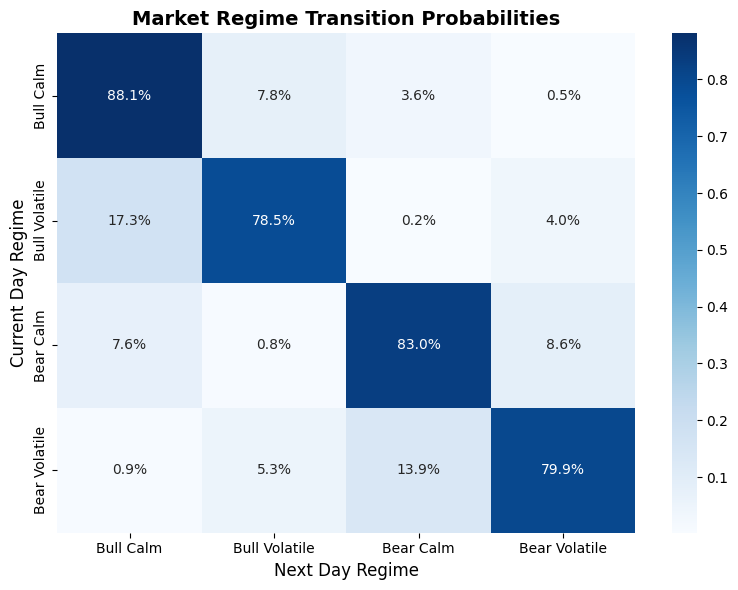

In [67]:
# Calculate day-to-day regime transitions
macro_df['Prev_Regime'] = macro_df['Regime'].shift(1)

# Create a cross-tabulation matrix normalized by row (probabilities sum to 1)
transition_matrix = pd.crosstab(macro_df['Prev_Regime'], macro_df['Regime'], normalize='index')

# Map the numerical indices to your regime names
regime_labels = ['Bull Calm', 'Bull Volatile', 'Bear Calm', 'Bear Volatile']
transition_matrix.index = regime_labels
transition_matrix.columns = regime_labels

plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt=".1%", cmap="Blues", cbar=True)
plt.title('Market Regime Transition Probabilities', fontsize=14, fontweight='bold')
plt.ylabel('Current Day Regime', fontsize=12)
plt.xlabel('Next Day Regime', fontsize=12)
plt.tight_layout()
plt.show()

In [68]:
# We have the 10-year 'returns_df' and 'macro_df'
#  We will use the static regime-wise approach here to generate the base weights per regime.

NUM_CLUSTERS = 6

def minimize_historical_var(weights, returns_matrix, alpha=5):
    """
    Objective Function: Calculates the 95% Historical VaR.
    We want SciPy to MINIMIZE this number (push the left-tail losses closer to zero).
    """
    # Calculate simulated portfolio returns using these weights
    portfolio_returns = np.dot(returns_matrix, weights)
    
    # Find the 5th percentile (95% confidence tail risk)
    # np.percentile returns a negative number for losses. 
    # We multiply by -1 to make it a positive loss figure for SciPy to minimize.
    var_95 = -np.percentile(portfolio_returns, alpha)
    return var_95

print("="*65)
print("PHASE 4: REGIME-WISE 95% VaR OPTIMIZATION (CENTROID PORTFOLIO)")
print("="*65)

# Dictionary to store our final target portfolios
regime_portfolios = {}

for target_regime in [1, 2, 3, 4]:
    # Isolate Regime Data
    regime_mask = macro_df['Regime'] == target_regime
    regime_returns = returns_df[regime_mask]
    
    if len(regime_returns) < 50:
        continue # Skip if not enough data
        
    # Re-calculate the specific clusters for this regime
    X_scaled = StandardScaler().fit_transform(regime_returns)
    pca = PCA(n_components=5, random_state=42)
    loadings = pca.fit(X_scaled).components_.T
    
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    kmeans.fit(loadings)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    
    # Find the "Medoid" (Closest Stock to Centroid) for each cluster
    medoid_stocks = []
    for i in range(NUM_CLUSTERS):
        # Get indices of stocks in this cluster
        cluster_indices = np.where(labels == i)[0]
        cluster_loadings = loadings[cluster_indices]
        
        # Find the single stock closest to the cluster's centroid
        closest_idx, _ = pairwise_distances_argmin_min([centroids[i]], cluster_loadings)
        
        # Map back to the actual stock ticker
        actual_stock_idx = cluster_indices[closest_idx[0]]
        medoid_stocks.append(returns_df.columns[actual_stock_idx])
        
    # Extract only the returns of those 6 specific stocks
    centroid_returns = regime_returns[medoid_stocks].values
    
    # SciPy Optimization Setup
    # Initial guess: Equal weight (1/6th each)
    init_guess = np.ones(NUM_CLUSTERS) / NUM_CLUSTERS
    
    # Bounds: No short selling (0.0 to 1.0) for each of the 6 stocks
    bounds = tuple((0.0, 1.0) for _ in range(NUM_CLUSTERS))
    
    # Constraints: The sum of all weights MUST equal 1.0 (100% invested)
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    
    # Run the Optimizer
    optimal_result = minimize(
        minimize_historical_var, 
        init_guess, 
        args=(centroid_returns,), 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    
    # Extract optimal weights and round them cleanly
    optimal_weights = np.round(optimal_result.x, 4)
    
    regime_portfolios[target_regime] = {
        'Stocks': medoid_stocks,
        'Weights': optimal_weights,
        'VaR_95': optimal_result.fun # The minimized VaR figure
    }

# DISPLAY OPTIMIZED PORTFOLIOS
regime_names = {1: '1. Bull Calm', 2: '2. Bull Volatile', 3: '3. Bear Calm', 4: '4. Bear Volatile'}

for regime, data in regime_portfolios.items():
    print(f"\n--- REGIME: {regime_names[regime]} ---")
    print(f"Target 95% VaR: {-data['VaR_95'] * 100:.2f}% (Max expected daily loss)")
    print("Optimal Target Weights:")
    
    # Print the specific stock and its optimal weight
    for stock, weight in zip(data['Stocks'], data['Weights']):
        # Only print stocks that actually received allocation (> 0.01%)
        if weight > 0.0001:
            print(f"  {stock}: {weight * 100:.2f}%")

PHASE 4: REGIME-WISE 95% VaR OPTIMIZATION (CENTROID PORTFOLIO)

--- REGIME: 1. Bull Calm ---
Target 95% VaR: -1.24% (Max expected daily loss)
Optimal Target Weights:
  SUNPHARMA.NS: 17.11%
  SHRIRAMFIN.NS: 12.40%
  COALINDIA.NS: 7.85%
  HCLTECH.NS: 23.41%
  TITAN.NS: 24.55%
  BAJAJFINSV.NS: 14.68%

--- REGIME: 2. Bull Volatile ---
Target 95% VaR: -1.51% (Max expected daily loss)
Optimal Target Weights:
  M&M.NS: 13.52%
  ASIANPAINT.NS: 10.28%
  DRREDDY.NS: 22.22%
  TECHM.NS: 18.38%
  POWERGRID.NS: 34.08%
  ICICIBANK.NS: 1.51%

--- REGIME: 3. Bear Calm ---
Target 95% VaR: -1.20% (Max expected daily loss)
Optimal Target Weights:
  INDUSINDBK.NS: 1.36%
  AXISBANK.NS: 7.22%
  WIPRO.NS: 28.89%
  ASIANPAINT.NS: 20.63%
  NTPC.NS: 12.11%
  CIPLA.NS: 29.79%

--- REGIME: 4. Bear Volatile ---
Target 95% VaR: -2.15% (Max expected daily loss)
Optimal Target Weights:
  SUNPHARMA.NS: 22.48%
  HINDALCO.NS: 0.07%
  HCLTECH.NS: 20.94%
  AXISBANK.NS: 1.76%
  NESTLEIND.NS: 40.65%
  ULTRACEMCO.NS: 14.10%


1. Computing Strategy 1: Static 100% Equity...
2. Computing Strategy 3: Dynamic Scaled...
3. Computing Strategy 2 (Static Scaled) and Strategy 4 (Nifty Benchmark Scaled)...

FINAL PERFORMANCE ATTRIBUTION TEARSHEET
Metric               | 1. Static 100%   | 2. Static Scaled | 3. Nifty Scaled | 4. Dynamic Scaled
-----------------------------------------------------------------------------------------------
Annualized Return (%) |           19.38% |           18.16% |           15.92% |           20.30% | 
Annualized Vol (%)   |           18.03% |           12.34% |           10.92% |           12.55% | 
Sharpe Ratio         |             0.80 |             1.07 |             1.00 |             1.22 | 
Max Drawdown (%)     |          -40.65% |          -21.43% |          -18.18% |          -12.55% | 
95% Daily VaR (%)    |           -1.57% |           -1.16% |           -1.00% |           -1.17% | 


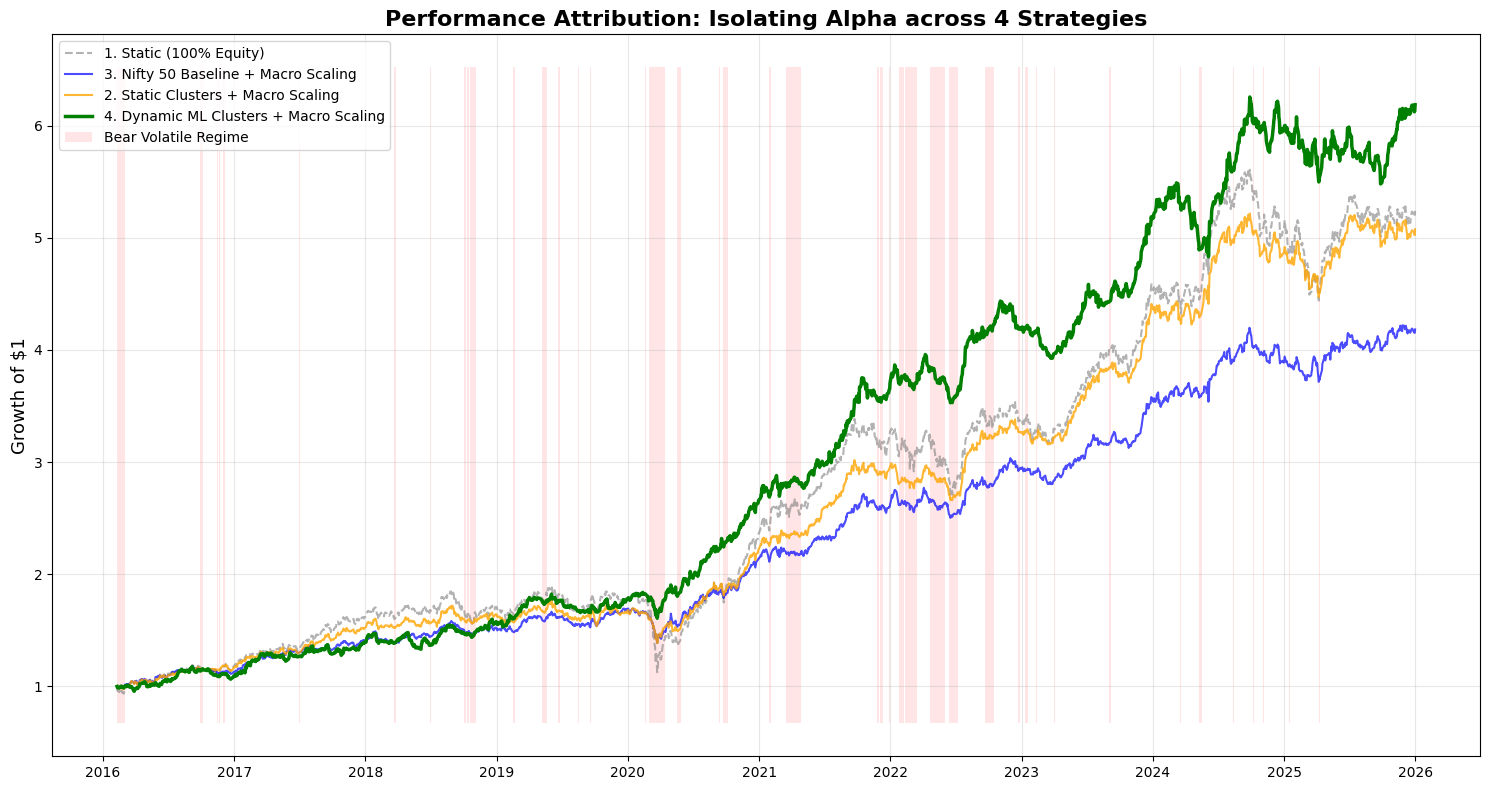

In [69]:
NUM_CLUSTERS = 6
ALPHA = 5 # 95% Confidence Level

ANNUAL_RISK_FREE_RATE = 0.05
DAILY_RF = ANNUAL_RISK_FREE_RATE / 252

# How much of the portfolio is invested in Equities vs Cash per regime?
EXPOSURE_MAP = {
    1: 1.00,  # Bull Calm: 100% Equity, 0% Cash
    2: 0.80,  # Bull Volatile: 80% Equity, 20% Cash
    3: 0.60,  # Bear Calm: 60% Equity, 40% Cash
    4: 0.40   # Bear Volatile: 40% Equity, 60% Cash
}

def minimize_var(weights, returns_matrix):
    port_returns = np.dot(returns_matrix, weights)
    return -np.percentile(port_returns, ALPHA)

def calculate_metrics(returns_series):
    var_95 = np.percentile(returns_series, ALPHA)
    ann_ret = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_ret - ANNUAL_RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0
    
    cum_returns = (1 + returns_series).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return var_95, ann_ret, ann_vol, sharpe, max_dd

# STRATEGY 1: STATIC BASELINE (100% EQUITY, 10-YEAR CLUSTERS)
print("1. Computing Strategy 1: Static 100% Equity...")
X_static = StandardScaler().fit_transform(returns_df)
loadings_static = PCA(n_components=5, random_state=42).fit(X_static).components_.T
kmeans_static = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
labels_static = kmeans_static.fit_predict(loadings_static)

static_medoids = []
for i in range(NUM_CLUSTERS):
    idx = np.where(labels_static == i)[0]
    closest, _ = pairwise_distances_argmin_min([kmeans_static.cluster_centers_[i]], loadings_static[idx])
    static_medoids.append(returns_df.columns[idx[closest[0]]])

static_matrix = returns_df[static_medoids].values
bounds = tuple((0.0, 1.0) for _ in range(NUM_CLUSTERS))
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

static_opt = minimize(minimize_var, np.ones(NUM_CLUSTERS)/NUM_CLUSTERS, args=(static_matrix,), 
                      method='SLSQP', bounds=bounds, constraints=constraints)

static_100_returns = pd.Series(np.dot(static_matrix, static_opt.x), index=returns_df.index)

# STRATEGY 3: DYNAMIC SCALED (REGIME-AWARE CLUSTERS + MACRO SCALING)
print("2. Computing Strategy 3: Dynamic Scaled...")
dynamic_scaled_returns = pd.Series(index=returns_df.index, dtype=float)

for regime in [1, 2, 3, 4]:
    regime_mask = macro_df['Regime'] == regime
    regime_data = returns_df[regime_mask]
    if len(regime_data) < 50: continue
        
    X_reg = StandardScaler().fit_transform(regime_data)
    loadings_reg = PCA(n_components=5, random_state=42).fit(X_reg).components_.T
    kmeans_reg = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    labels_reg = kmeans_reg.fit_predict(loadings_reg)
    
    regime_medoids = []
    for i in range(NUM_CLUSTERS):
        idx = np.where(labels_reg == i)[0]
        closest, _ = pairwise_distances_argmin_min([kmeans_reg.cluster_centers_[i]], loadings_reg[idx])
        regime_medoids.append(returns_df.columns[idx[closest[0]]])
        
    regime_matrix = regime_data[regime_medoids].values
    regime_opt = minimize(minimize_var, np.ones(NUM_CLUSTERS)/NUM_CLUSTERS, args=(regime_matrix,), 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    
    equity_returns = np.dot(regime_matrix, regime_opt.x)
    
    equity_weight = EXPOSURE_MAP[regime]
    cash_weight = 1.0 - equity_weight
    dynamic_scaled_returns.loc[regime_mask] = (equity_returns * equity_weight) + (DAILY_RF * cash_weight)

dynamic_scaled_returns.fillna(0, inplace=True)


# STRATEGIES 2 & 4: STATIC SCALED AND NIFTY 50 SCALED
print("3. Computing Strategy 2 (Static Scaled) and Strategy 4 (Nifty Benchmark Scaled)...")

# Approximate the Nifty 50 as an Equal Weight representation of your 50 stocks
nifty_ew_returns = features['Close'].pct_change().reindex(returns_df.index)

static_scaled_returns = pd.Series(index=returns_df.index, dtype=float)
nifty_scaled_returns = pd.Series(index=returns_df.index, dtype=float)

for regime in [1, 2, 3, 4]:
    regime_mask = macro_df['Regime'] == regime
    equity_weight = EXPOSURE_MAP[regime]
    cash_weight = 1.0 - equity_weight
    
    # Strategy 2: Scale the Static 10-Year Medoid portfolio
    static_scaled_returns.loc[regime_mask] = (static_100_returns.loc[regime_mask] * equity_weight) + (DAILY_RF * cash_weight)
    
    # Strategy 4: Scale the raw Nifty 50
    nifty_scaled_returns.loc[regime_mask] = (nifty_ew_returns.loc[regime_mask] * equity_weight) + (DAILY_RF * cash_weight)

# TEARSHEET & VISUALIZATION
portfolios = {
    "1. Static 100% Equity": static_100_returns,
    "2. Static Scaled": static_scaled_returns,
    "3. Nifty 50 Scaled": nifty_scaled_returns,
    "4. Dynamic Scaled": dynamic_scaled_returns
}

results = {}
for name, rets in portfolios.items():
    var, ann_ret, ann_vol, sharpe, max_dd = calculate_metrics(rets)
    results[name] = [ann_ret*100, ann_vol*100, sharpe, max_dd*100, var*100]

print("\n" + "="*95)
print("FINAL PERFORMANCE ATTRIBUTION TEARSHEET")
print("="*95)
print(f"{'Metric':<20} | {'1. Static 100%':<16} | {'2. Static Scaled':<16} | {'3. Nifty Scaled':<15} | {'4. Dynamic Scaled':<17}")
print("-" * 95)
metrics_names = ['Annualized Return (%)', 'Annualized Vol (%)', 'Sharpe Ratio', 'Max Drawdown (%)', '95% Daily VaR (%)']

for i, metric in enumerate(metrics_names):
    row = f"{metric:<20} | "
    for name in portfolios.keys():
        val = results[name][i]
        # Format Sharpe ratio without % sign
        if i == 2: 
            row += f"{val:>16.2f} | "
        else:
            row += f"{val:>15.2f}% | "
    print(row)
print("="*95)

# --- PLOT THE EQUITY CURVES ---
plt.figure(figsize=(15, 8))

# 1. Static 100% (The Naive Baseline)
cum_1 = (1 + static_100_returns).cumprod()
plt.plot(cum_1.index, cum_1, color='gray', linestyle='--', alpha=0.6, label='1. Static (100% Equity)')

# 3. Nifty 50 Scaled (The Market Timing Baseline)
cum_3 = (1 + nifty_scaled_returns).cumprod()
plt.plot(cum_3.index, cum_3, color='blue', alpha=0.7, label='3. Nifty 50 Baseline + Macro Scaling')

# 2. Static Scaled (The Cluster Selection Baseline)
cum_2 = (1 + static_scaled_returns).cumprod()
plt.plot(cum_2.index, cum_2, color='orange', alpha=0.8, linewidth=1.5, label='2. Static Clusters + Macro Scaling')

# 4. Dynamic Scaled (The Holy Grail)
cum_4 = (1 + dynamic_scaled_returns).cumprod()
plt.plot(cum_4.index, cum_4, color='green', linewidth=2.5, label='4. Dynamic ML Clusters + Macro Scaling')

plt.title('Performance Attribution: Isolating Alpha across 4 Strategies', fontsize=16, fontweight='bold')
plt.ylabel('Growth of $1', fontsize=13)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

# Shade the Bear Volatile regimes
for regime in [4]:
    mask = macro_df['Regime'] == regime
    plt.fill_between(macro_df.index, plt.ylim()[0], plt.ylim()[1], where=mask, facecolor='red', alpha=0.10, label='Bear Volatile Regime')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()

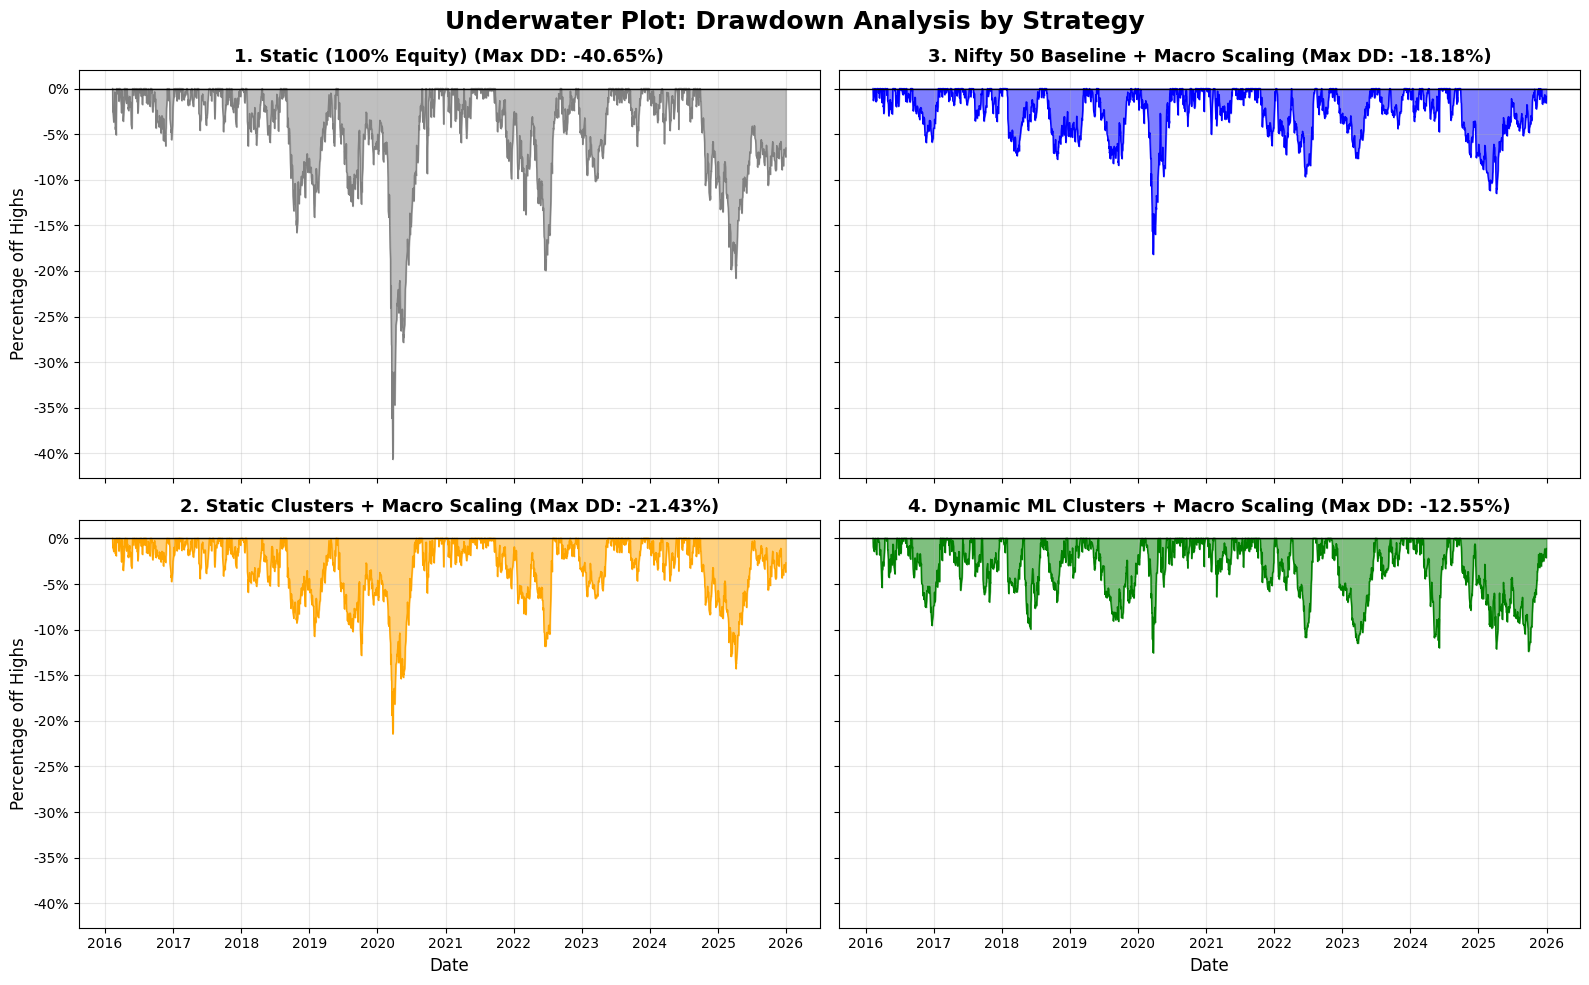

In [70]:
# UNDERWATER DRAWDOWN PLOTS (2x2 GRID)
# Calculate Drawdowns for all 4 strategies using the cumulative returns
dd_1 = (cum_1 - cum_1.cummax()) / cum_1.cummax()
dd_2 = (cum_2 - cum_2.cummax()) / cum_2.cummax()
dd_3 = (cum_3 - cum_3.cummax()) / cum_3.cummax()
dd_4 = (cum_4 - cum_4.cummax()) / cum_4.cummax()

# Setup for the plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True, sharex=True)
fig.suptitle('Underwater Plot: Drawdown Analysis by Strategy', fontsize=18, fontweight='bold')

# Helper function to format the subplots consistently
def plot_drawdown(ax, drawdown_series, color, title):
    ax.fill_between(drawdown_series.index, drawdown_series, 0, color=color, alpha=0.5)
    ax.plot(drawdown_series.index, drawdown_series, color=color, linewidth=1)
    ax.set_title(f'{title} (Max DD: {drawdown_series.min():.2%})', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.axhline(0, color='black', linewidth=1) # The "Water Surface"

# Plot each strategy
# Top Left: Static 100%
plot_drawdown(axes[0, 0], dd_1, 'gray', '1. Static (100% Equity)')

# Top Right: Nifty 50 Scaled
plot_drawdown(axes[0, 1], dd_3, 'blue', '3. Nifty 50 Baseline + Macro Scaling')

# Bottom Left: Static Scaled
plot_drawdown(axes[1, 0], dd_2, 'orange', '2. Static Clusters + Macro Scaling')

# Bottom Right: Dynamic Scaled (The Full Model)
plot_drawdown(axes[1, 1], dd_4, 'green', '4. Dynamic ML Clusters + Macro Scaling')

# Formatting labels
for ax in axes[1, :]:
    ax.set_xlabel('Date', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel('Percentage off Highs', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Give the main title room to breathe
plt.show()